In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/clean_customer_churn.csv")


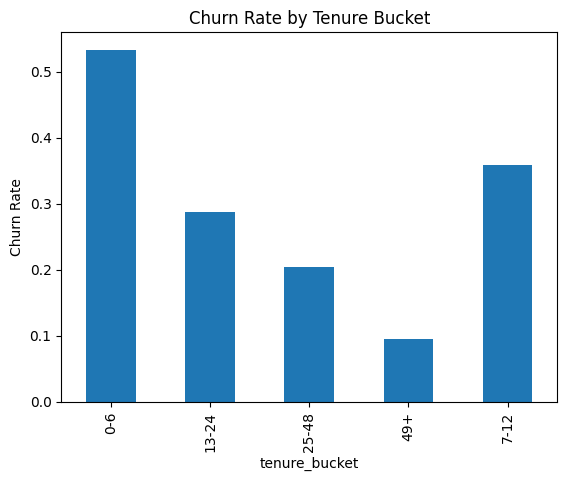

In [2]:
tenure_churn = df.groupby("tenure_bucket")["churn_value"].mean()

tenure_churn.plot(kind="bar")
plt.title("Churn Rate by Tenure Bucket")
plt.ylabel("Churn Rate")
plt.show()


Customers with tenure below 6 months exhibit the highest churn, indicating onboarding and early engagement gaps.

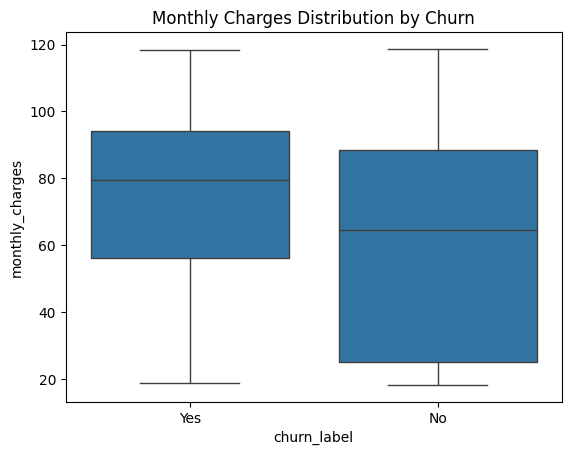

In [3]:
sns.boxplot(x="churn_label", y="monthly_charges", data=df)
plt.title("Monthly Charges Distribution by Churn")
plt.show()


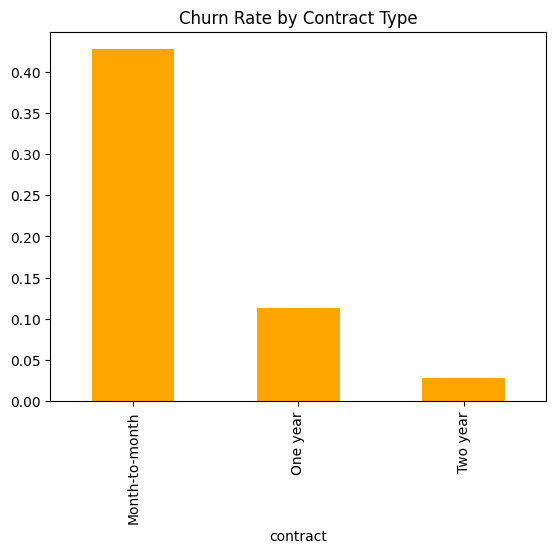

In [4]:
contract_churn = df.groupby("contract")["churn_value"].mean()

contract_churn.plot(kind="bar", color="orange")
plt.title("Churn Rate by Contract Type")
plt.show()


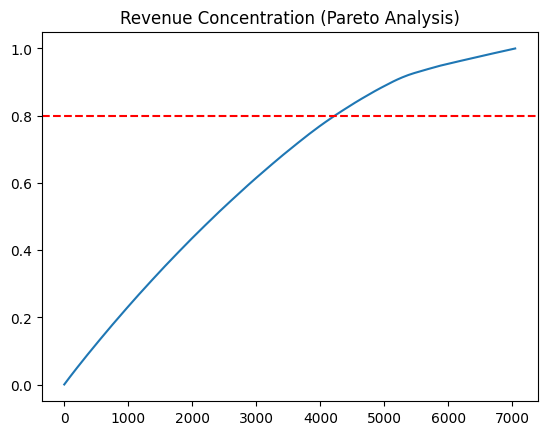

In [5]:
revenue_df = df.groupby("customerid")["monthly_charges"].sum().sort_values(ascending=False)
revenue_df = revenue_df.cumsum() / revenue_df.sum()

plt.plot(revenue_df.values)
plt.axhline(0.8, color="red", linestyle="--")
plt.title("Revenue Concentration (Pareto Analysis)")
plt.show()


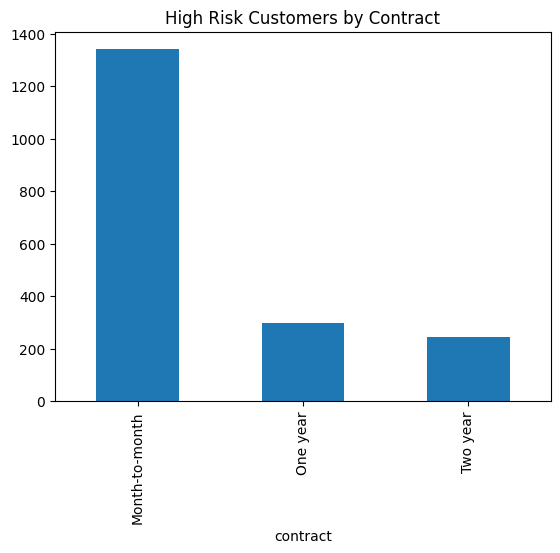

In [6]:
high_risk = df[df["churn_risk_score"] > 0.7]

high_risk["contract"].value_counts().plot(kind="bar")
plt.title("High Risk Customers by Contract")
plt.show()
